Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

In [3]:
automobiles_df.head()
automobiles_df.info()
automobiles_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [4]:
import pandas as pd
# First check for the missing data
missing_data = automobiles_df.isnull().sum()
print(missing_data)

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [5]:
# Removing the two columns wwith is symboling and normalizing-losses from the dataset
df = automobiles_df.drop(columns=['normalized-losses', 'symboling'])
print(df)

            make fuel-type aspiration num-of-doors   body-style drive-wheels  \
0    alfa-romero       gas        std          two  convertible          rwd   
1    alfa-romero       gas        std          two  convertible          rwd   
2    alfa-romero       gas        std          two    hatchback          rwd   
3           audi       gas        std         four        sedan          fwd   
4           audi       gas        std         four        sedan          4wd   
..           ...       ...        ...          ...          ...          ...   
200        volvo       gas        std         four        sedan          rwd   
201        volvo       gas      turbo         four        sedan          rwd   
202        volvo       gas        std         four        sedan          rwd   
203        volvo    diesel      turbo         four        sedan          rwd   
204        volvo       gas      turbo         four        sedan          rwd   

    engine-location  wheel-base  length

#### Remove any duplicate rows

In [6]:
# Removing duplicates
df_clean = df.drop_duplicates()
print(df_clean)

            make fuel-type aspiration num-of-doors   body-style drive-wheels  \
0    alfa-romero       gas        std          two  convertible          rwd   
1    alfa-romero       gas        std          two  convertible          rwd   
2    alfa-romero       gas        std          two    hatchback          rwd   
3           audi       gas        std         four        sedan          fwd   
4           audi       gas        std         four        sedan          4wd   
..           ...       ...        ...          ...          ...          ...   
200        volvo       gas        std         four        sedan          rwd   
201        volvo       gas      turbo         four        sedan          rwd   
202        volvo       gas        std         four        sedan          rwd   
203        volvo    diesel      turbo         four        sedan          rwd   
204        volvo       gas      turbo         four        sedan          rwd   

    engine-location  wheel-base  length

In [7]:
# Discard rows with any missing values
automobiles_df = automobiles_df.dropna()

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [8]:
# changing columns with numerical data to integers using numpy's int64
numerical_data_col = df_clean.select_dtypes(include=['float64']).columns
print(numerical_data_col)

Index(['wheel-base', 'length', 'width', 'height', 'compression-ratio'], dtype='object')


In [9]:
# Converting numerical data to int64
df_clean[numerical_data_col] = df_clean[numerical_data_col].astype(np.int64)
print(df_clean[numerical_data_col])

     wheel-base  length  width  height  compression-ratio
0            88     168     64      48                  9
1            88     168     64      48                  9
2            94     171     65      52                  9
3            99     176     66      54                 10
4            99     176     66      54                  8
..          ...     ...    ...     ...                ...
200         109     188     68      55                  9
201         109     188     68      55                  8
202         109     188     68      55                  8
203         109     188     68      55                 23
204         109     188     68      55                  9

[205 rows x 5 columns]


In [10]:
# Convert columns to appropriate data types
numerical_data_cols = ['price', 'horsepower', 'city-mpg']
automobiles_df[numerical_data_cols] = automobiles_df[numerical_data_cols].apply(pd.to_numeric, errors='coerce')

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [11]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars = df[df['body-style'] == 'hatchback']
print(hatchback_cars)

            make fuel-type aspiration num-of-doors body-style drive-wheels  \
2    alfa-romero       gas        std          two  hatchback          rwd   
9           audi       gas      turbo          two  hatchback          4wd   
18     chevrolet       gas        std          two  hatchback          fwd   
19     chevrolet       gas        std          two  hatchback          fwd   
21         dodge       gas        std          two  hatchback          fwd   
..           ...       ...        ...          ...        ...          ...   
175       toyota       gas        std         four  hatchback          fwd   
177       toyota       gas        std         four  hatchback          fwd   
178       toyota       gas        std          two  hatchback          rwd   
179       toyota       gas        std          two  hatchback          rwd   
190   volkswagen       gas        std          two  hatchback          fwd   

    engine-location  wheel-base  length  width  ...  engine-siz

In [12]:
automobiles_df = automobiles_df.replace('?', np.nan)
print(automobiles_df)

     symboling normalized-losses         make fuel-type aspiration  \
0            3               NaN  alfa-romero       gas        std   
1            3               NaN  alfa-romero       gas        std   
2            1               NaN  alfa-romero       gas        std   
3            2               164         audi       gas        std   
4            2               164         audi       gas        std   
..         ...               ...          ...       ...        ...   
200         -1                95        volvo       gas        std   
201         -1                95        volvo       gas      turbo   
202         -1                95        volvo       gas        std   
203         -1                95        volvo    diesel      turbo   
204         -1                95        volvo       gas      turbo   

    num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0            two  convertible          rwd           front        88.6  ...   
1

### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

In [13]:
# First ensure that the price column is numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')
most_expensive_cars = df.nlargest(5, 'price')
print(most_expensive_cars[['make', 'price']])

              make    price
74   mercedes-benz  45400.0
16             bmw  41315.0
73   mercedes-benz  40960.0
128        porsche  37028.0
17             bmw  36880.0


In [14]:
# Converting the horsepower column to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors= 'coerce')
df = df.dropna(subset=['horsepower'])

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

In [15]:
avg_mpg_by_manufacturer = df.groupby(by='make')['highway-mpg'].mean().sort_values(ascending=False)
print(avg_mpg_by_manufacturer)

make
chevrolet        46.333333
isuzu            36.000000
honda            35.461538
volkswagen       34.916667
plymouth         34.142857
dodge            34.111111
nissan           32.944444
toyota           32.906250
mazda            31.941176
mitsubishi       31.153846
subaru           30.750000
saab             27.333333
alfa-romero      26.666667
peugot           26.636364
porsche          26.000000
volvo            25.818182
bmw              25.375000
audi             24.142857
mercury          24.000000
mercedes-benz    21.000000
jaguar           18.333333
Name: highway-mpg, dtype: float64


In [16]:
# Converting the bore column to numeric
df['bore'] = pd.to_numeric(df['bore'], errors = 'coerce')
df = df.dropna(subset=['bore'])

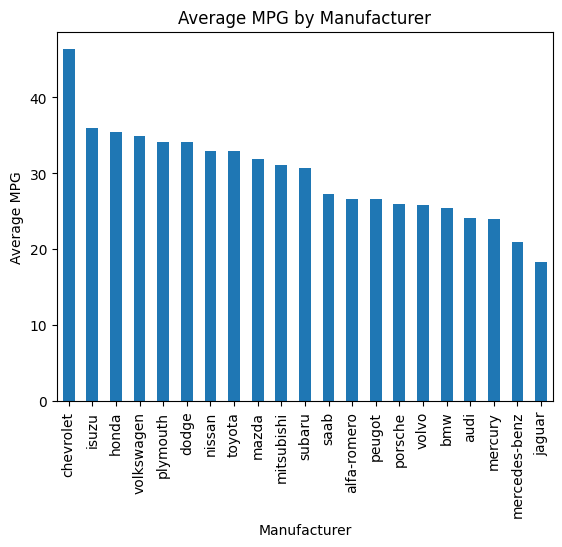

In [17]:
avg_mpg_by_manufacturer.plot(kind='bar')
plt.title('Average MPG by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average MPG')
plt.show()

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [18]:
largest_engines = df.nlargest(5, 'engine-size')
print(largest_engines[['make', 'engine-size']])

             make  engine-size
49         jaguar          326
73  mercedes-benz          308
74  mercedes-benz          304
47         jaguar          258
48         jaguar          258


#### Which vehicle manufacturer has the most car models in the dataset

In [19]:
models_per_manufacturer = df['make'].value_counts()
print(models_per_manufacturer.head())

make
toyota        32
nissan        18
mazda         13
honda         13
mitsubishi    13
Name: count, dtype: int64


# Visualisations:
1. Distribution of car models:
One can plot a bar graph showing the frequency of differentcar models (like Audi, BMW, Chevrolet, etc.).
2. Body type vs dimension :
Visualising how different body types (sedan, hatchback, wagon, etc.) correlate with dimensions like length, width, height.
3. Engine type and fuel type distribution:
A chart showing the distribution of fuel types (petrol, diesel) and engine types like turbo.

# Investigations 
1. Car attributes correlation:
Investigate if there's a correlation between car dimensions (length,width, height) and other attributes like body type or engine type.
2. Popular car types in the dataset:
Look into which models are most common.
3. Outliers in dimensions:
Check for any outliers in car dimensions that might indicate anomalies or special vehicle types.

# Findings
1. Certain car models might be more prevalent in the dataset.
2. There could be patterns in dimensions based on body type (e.g. hatchbacks tend to be shorter).
3. Fuel type distribution might lean towards one type over the other based on region or car type popularity.

# Manufacturer frequency bar plot
It shows how many vehicles each make contributes to the dataset. It is useful for seeing which brands are most represented.

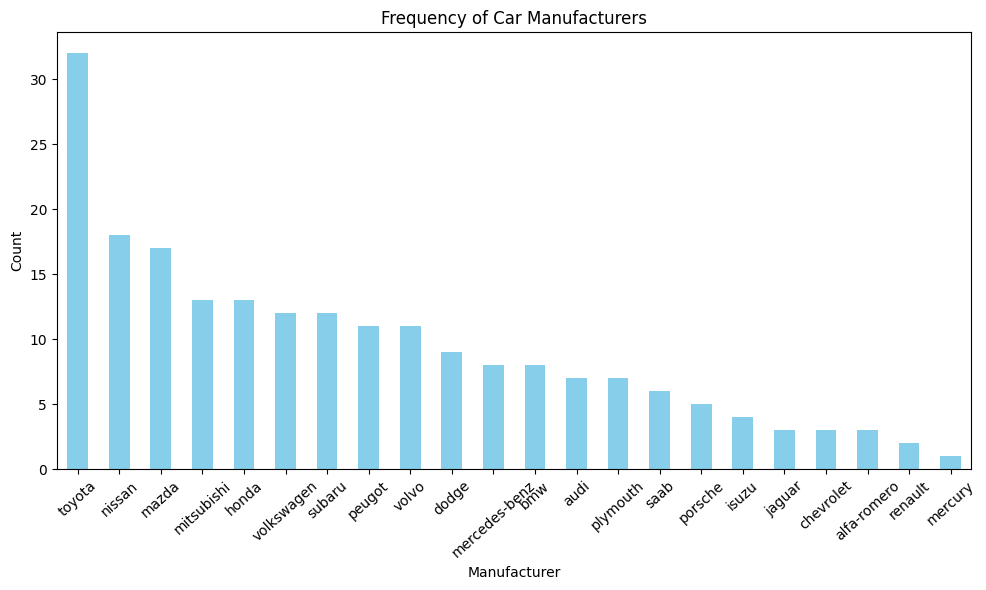

In [36]:
# Bar plot of manufacturer frequency
plt.figure(figsize=(10, 6))
make_counts = automobiles_df['make'].value_counts()
make_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Car Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.xticks(rotation=42)
plt.tight_layout()
plt.show()

# Engine-size vs Price Scatter plot
It shows the relationship between engine-size and price. 
Generally, larrger engines are associated with higher prices (positive trend).

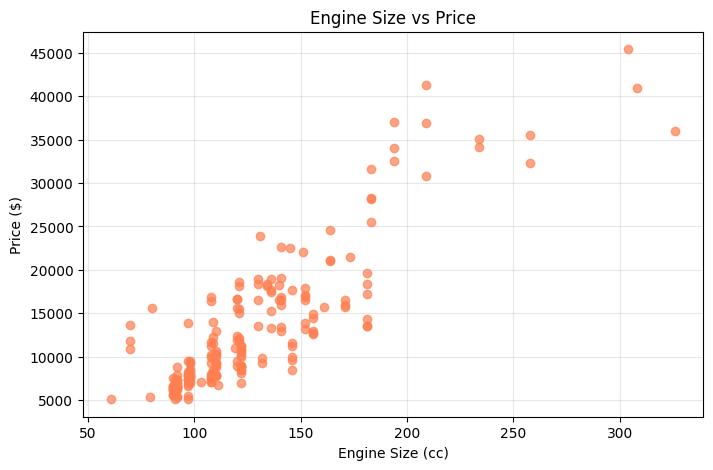

In [24]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(automobiles_df['engine-size'], automobiles_df['price'], alpha=0.7, color='coral')
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size (cc)')
plt.ylabel('Price ($)')
plt.grid(alpha=0.3)
plt.show()

# Correlation heatmap
It visualises the correlation coefficients between numeric values(e.g. engine-size, price, horsepower). 
Values near +1 indicate strong positive correlation, near -1 indicates strong negative correlation.

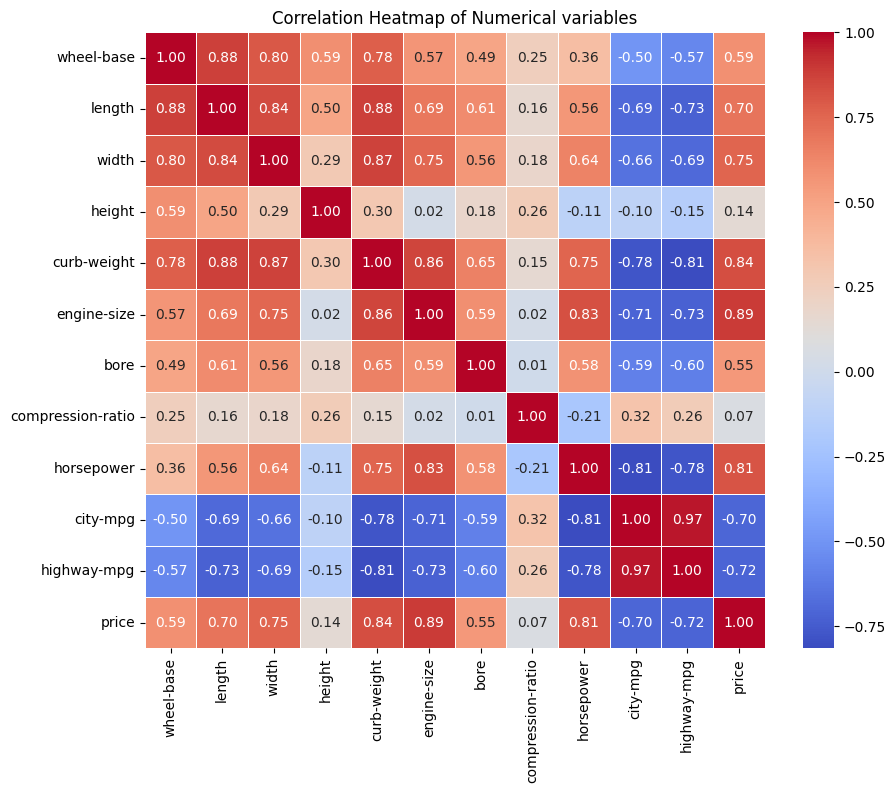

In [34]:
# Correlation heatmap (for numeric columns)
numerical_data_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_data_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical variables')
plt.show()

# Body-style boxplot
It compares the price distribution across different body styles (sedan, hatchback, convertible, etc.), highlighting median prices and potential outliers.

C:\Users\maleb\AppData\Local\Temp\ipykernel_4112\1799165305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body-style', y='price', data=automobiles_df, palette='Set2')


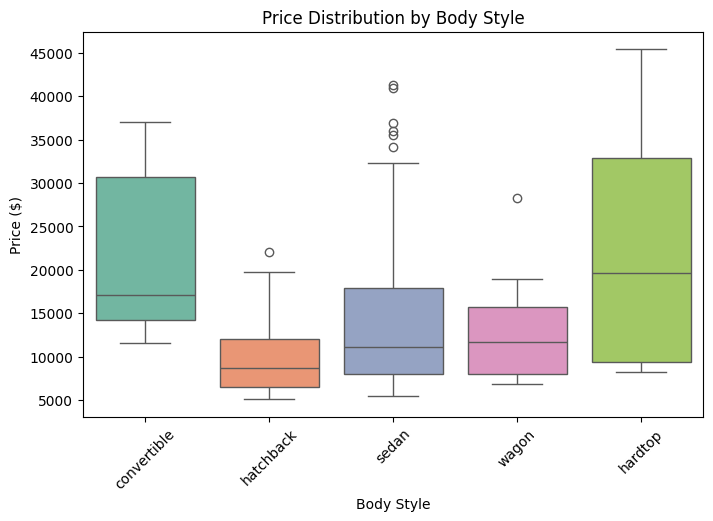

In [35]:
# Body-style comparision (boxplot of price by Body Style)
plt.figure(figsize=(8, 5))
sns.boxplot(x='body-style', y='price', data=automobiles_df, palette='Set2')
plt.title('Price Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.show()